In [209]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')


## 1: Load and Preprocess Data

In [210]:
# Load fully feature-engineered dataset
df = pd.read_csv("feature_engineering/data_with_new_features_v3.csv")
participant_col_name = 'participant'

### Select Features

In [211]:
import re

def select_feature_groups(df, group_names):
    base = ['timestamp', 'participant', 'genre']

    groups = {
        "raw": [
            'heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm',
            'iris_diameter_mm', 'pupil_iris_ratio'],
        'head_movement':['head_displacement', 'head_velocity', 'head_direction_change_rate', 'head_stability', 'centered_x', 'centered_y'],
        "time_domain": [col for col in df.columns if col.startswith("td_")],
        "fft": [col for col in df.columns if "_fft_" in col],
        "entropy": [col for col in df.columns if "_entropy" in col],
        "stat_moments": [col for col in df.columns if any(k in col for k in ['_skew', '_kurtosis'])],
        "bucket": [col for col in df.columns if col.endswith("_bucket")],
        "bucket_transitions": [col for col in df.columns if re.match(r'.*_(low|normal|high)_(low|normal|high)$', col)],
        "nonlinear": [col for col in df.columns if "_entropy" in col or "_sample_entropy" in col or "_approx_entropy" in col],
    }

    selected = set(base)
    for name in group_names:
        selected.update(groups.get(name, []))

    return df[list(selected)]


df = select_feature_groups(df, ['raw', 'head_movement'])

### Encoding & Scaling

In [212]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [213]:
# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference(exclude_cols)

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])


## 2. Train/Val/Test Split by Participants

In [214]:
# Split Clara for test only
test_df = df[df[participant_col_name] == 'clara'].copy()

# Combine Kenji and Aimen data
train_val_df = df[df[participant_col_name].isin(['kenji', 'aimen'])].copy()

# Stratified split into train (80%) and val (20%) from Kenji + Aimen
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['genre_encoded'],
    random_state=42
)

# Final test set is Clara
final_test_df = test_df.copy()

In [215]:
train_df

,timestamp,participant,head_velocity,iris_diameter_mm,head_stability,pupil_iris_ratio,head_direction_change_rate,heart_rate,centered_x,x_coordinate,head_displacement,genre,y_coordinate,pupil_diameter_mm,centered_y,genre_encoded
7541,2025-06-12 09:59:01,aimen,-0.326559,0.0,-0.626387,-0.764484,0.454211,0.188650,-0.376383,-0.871654,-0.361682,comedy,-0.435067,-0.764484,0.928462,0
756,2025-06-05 16:50:11,kenji,1.105791,0.0,0.660210,-0.469290,1.968853,-1.467929,0.476177,-0.816592,1.765326,comedy,-1.156817,-0.469290,-0.844875,0
8622,2025-06-12 10:20:58,aimen,1.400205,0.0,0.025618,0.862913,0.113765,0.143904,-0.218736,-0.834606,0.867999,horror,-1.332525,0.862913,-1.331153,2
8972,2025-06-12 10:26:55,aimen,-0.448684,0.0,-0.664963,0.209050,-3.108382,0.765005,4.011680,0.159560,-0.448651,horror,-1.751811,0.209050,-2.386830,2
2671,2025-06-05 18:23:31,kenji,2.135024,0.0,2.373706,1.633319,1.450021,0.131785,-0.251911,-0.987696,3.231223,horror,-0.742166,1.633319,0.199132,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7267,2025-06-12 09:29:52,aimen,-0.430316,0.0,-0.630027,-1.072893,0.767296,1.998117,-0.563999,-0.915745,-0.435571,documentary,-0.179799,-1.072893,1.571177,1
1373,2025-06-05 17:27:13,kenji,-0.444859,0.0,-0.613088,-0.471563,0.112154,-2.134476,-0.340787,-1.008583,-0.440480,documentary,-0.542195,-0.471563,0.702619,1
1274,2025-06-05 17:23:53,kenji,-0.438341,0.0,-0.541330,-0.417095,0.780699,-1.601238,-0.555498,-1.059040,-0.426555,documentary,-0.562721,-0.417095,0.650936,1
8274,2025-06-12 10:15:10,aimen,-0.377921,0.0,-0.577307,1.345109,0.189670,-0.134834,-0.998901,-1.017948,-0.398259,horror,-1.372065,1.345109,-1.430707,2


In [216]:
print(set(train_df['participant'].values))
print(set(val_df['participant'].values))
print(set(final_test_df['participant'].values))

{'aimen', 'kenji'}
{'aimen', 'kenji'}
{'clara'}


In [217]:
print(set(train_df['genre'].values))
print(set(val_df['genre'].values))
print(set(final_test_df['genre'].values))

print(train_df['genre_encoded'].value_counts())
print(val_df['genre_encoded'].value_counts())
print(final_test_df['genre_encoded'].value_counts())

{'horror', 'comedy', 'documentary'}
{'documentary', 'comedy', 'horror'}
{'documentary', 'comedy', 'horror'}
genre_encoded
2    1705
0    1297
1    1183
Name: count, dtype: int64
genre_encoded
2    427
0    324
1    296
Name: count, dtype: int64
genre_encoded
1    1560
0    1340
2    1212
Name: count, dtype: int64


In [218]:
# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

## 3. RFECV for Feature Selection

In [219]:
rf = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_weighted', n_jobs=-1)
rfecv.fit(X_train, y_train)

# Reduce features
X_train_sel = rfecv.transform(X_train)
X_val_sel = rfecv.transform(X_val)
X_test_sel = rfecv.transform(X_test)


In [220]:
selected_feature_mask = rfecv.support_
selected_feature_names = X_train.columns[rfecv.support_]
print("Selected features:", selected_feature_names.tolist())

Selected features: ['head_velocity', 'iris_diameter_mm', 'head_stability', 'pupil_iris_ratio', 'head_direction_change_rate', 'heart_rate', 'centered_x', 'x_coordinate', 'head_displacement', 'y_coordinate', 'pupil_diameter_mm', 'centered_y']


In [221]:
feature_ranks = pd.DataFrame({
    'feature': X_train.columns,
    'rank': rfecv.ranking_
}).sort_values(by='rank')

print(feature_ranks)

                       feature  rank
0                head_velocity     1
1             iris_diameter_mm     1
2               head_stability     1
3             pupil_iris_ratio     1
4   head_direction_change_rate     1
5                   heart_rate     1
6                   centered_x     1
7                 x_coordinate     1
8            head_displacement     1
9                 y_coordinate     1
10           pupil_diameter_mm     1
11                  centered_y     1


## 4. Train and Evaluate Final Random Forest

In [222]:
rf_final = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
rf_final.fit(X_train_sel, y_train)

# Validation
val_preds = rf_final.predict(X_val_sel)
print("Validation Report:\n", classification_report(y_val, val_preds))

# Test
test_preds = rf_final.predict(X_test_sel)
print("Test Report:\n", classification_report(y_test, test_preds))

Validation Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       324
           1       0.98      0.99      0.99       296
           2       0.99      1.00      0.99       427

    accuracy                           0.99      1047
   macro avg       0.99      0.99      0.99      1047
weighted avg       0.99      0.99      0.99      1047

Test Report:
               precision    recall  f1-score   support

           0       0.56      0.58      0.57      1340
           1       0.68      0.73      0.70      1560
           2       0.86      0.74      0.80      1212

    accuracy                           0.69      4112
   macro avg       0.70      0.68      0.69      4112
weighted avg       0.69      0.69      0.69      4112



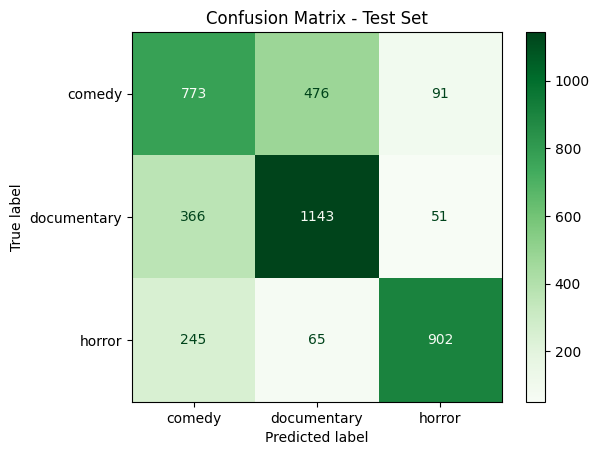

In [223]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test confusion matrix
test_cm = confusion_matrix(y_test, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=genre_label_encoder.classes_)
test_disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Test Set")
plt.show()
